# Craigslist Vehicles Lakehouse (DuckDB)
## Bronze → Silver → Gold + 10 Insight Queries (with charts)

This notebook builds a teaching-grade **Lakehouse** over `vehicles.csv` using DuckDB only (**no Parquet**).

![ETL Diagram](vehicles_lakehouse_etl_diagram.png)


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("vehicles.csv")
DB_PATH = Path("vehicles_lakehouse.duckdb")

con = duckdb.connect(str(DB_PATH))
print("DuckDB:", duckdb.__version__)


DuckDB: 1.4.4


## 1) Bronze: raw view

In [ ]:
con.execute("""
DROP VIEW IF EXISTS bronze_vehicles;

CREATE VIEW bronze_vehicles AS
SELECT *
FROM read_csv_auto(
  'vehicles.csv',
  header=true,
  sample_size=50000,
  ignore_errors=true
);
""")

In [3]:
con.execute("SELECT COUNT(*) AS row_count FROM bronze_vehicles;").df()

,row_count
0,426880


In [5]:
con.execute("SELECT * FROM bronze_vehicles limit 4;").df()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,<NA>,None,None,None,None,...,None,None,None,None,None,None,az,NaN,NaN,NaT
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,<NA>,None,None,None,None,...,None,None,None,None,None,None,ar,NaN,NaN,NaT
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,<NA>,None,None,None,None,...,None,None,None,None,None,None,fl,NaN,NaN,NaT
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,<NA>,None,None,None,None,...,None,None,None,None,None,None,ma,NaN,NaN,NaT


## 2) Silver: cleaned and standardized table

In [12]:
con.execute("""
DROP TABLE IF EXISTS silver_vehicles;

CREATE TABLE silver_vehicles AS
WITH base AS (
  SELECT
    id,
    url,
    region,
    region_url,
    TRY_CAST(price AS BIGINT) AS price,
    TRY_CAST(year AS INTEGER) AS vehicle_year,
    lower(trim(CAST(manufacturer AS VARCHAR))) AS manufacturer,
    lower(trim(CAST(model AS VARCHAR))) AS model,
    lower(trim(CAST(condition AS VARCHAR))) AS condition,
    lower(trim(CAST(cylinders AS VARCHAR))) AS cylinders,
    lower(trim(CAST(fuel AS VARCHAR))) AS fuel,
    TRY_CAST(odometer AS BIGINT) AS odometer,
    lower(trim(CAST(title_status AS VARCHAR))) AS title_status,
    lower(trim(CAST(transmission AS VARCHAR))) AS transmission,
    CAST(VIN AS VARCHAR) AS vin,
    lower(trim(CAST(drive AS VARCHAR))) AS drive,
    lower(trim(CAST(size AS VARCHAR))) AS size,
    lower(trim(CAST(type AS VARCHAR))) AS type,
    lower(trim(CAST(paint_color AS VARCHAR))) AS paint_color,
    image_url,
    description,
    county,
    lower(trim(CAST(state AS VARCHAR))) AS state,
    TRY_CAST(lat AS DOUBLE) AS lat,
    TRY_CAST(long AS DOUBLE) AS lon,

    -- IMPORTANT FIX
    posting_date AS posting_ts

  FROM bronze_vehicles
),
enriched AS (
  SELECT
    *,
    posting_ts::DATE AS posting_date,
    EXTRACT(year FROM posting_ts) AS posting_year,
    EXTRACT(month FROM posting_ts) AS posting_month,

    CASE
      WHEN vehicle_year IS NULL OR posting_ts IS NULL THEN NULL
      ELSE EXTRACT(year FROM posting_ts) - vehicle_year
    END AS vehicle_age,

    CASE
      WHEN odometer IS NULL OR odometer = 0 OR price IS NULL THEN NULL
      ELSE price::DOUBLE / odometer::DOUBLE
    END AS price_per_mile

  FROM base
)

SELECT *
FROM enriched
WHERE
  price BETWEEN 500 AND 200000
  AND (vehicle_year BETWEEN 1950 AND EXTRACT(year FROM CURRENT_DATE) OR vehicle_year IS NULL)
  AND (odometer BETWEEN 0 AND 500000 OR odometer IS NULL);
""")

In [13]:
con.execute("SELECT COUNT(*) AS row_count FROM silver_vehicles;").df()

,row_count
0,382432


In [14]:
con.execute("""
SELECT
  COUNT(*) AS total_rows,
  COUNT(posting_date) AS non_null_posting_date
FROM silver_vehicles
""").df()

,total_rows,non_null_posting_date
0,382432,382370


## 3) Gold: curated KPI view

In [ ]:
con.execute("""
DROP VIEW IF EXISTS gold_kpi_month;

CREATE VIEW gold_kpi_month AS
SELECT
  date_trunc('month', posting_date) AS month,
  COUNT(*) AS listings,
  MEDIAN(price) AS median_price,
  QUANTILE_CONT(price, 0.90) AS p90_price,
  AVG(price) AS avg_price
FROM silver_vehicles
WHERE posting_date IS NOT NULL
GROUP BY 1
ORDER BY 1;
""")

In [16]:
con.execute("SELECT COUNT(*) AS row_count FROM gold_kpi_month;").df()

,row_count
0,2


In [17]:
con.execute("SELECT * FROM gold_kpi_month LIMIT 12;").df()

,month,listings,median_price,p90_price,avg_price
0,2021-04-01,284845,16300.0,38990.0,19797.460394
1,2021-05-01,97525,13995.0,35995.0,17899.389336


## 4) Chart helpers

In [18]:
def plot_line_time(df, x, y, title):
    plt.figure(figsize=(10,4))
    plt.plot(df[x], df[y])
    plt.title(title)
    plt.xlabel(x); plt.ylabel(y)
    plt.tight_layout(); plt.show()

def plot_line_num(df, x, y, title):
    plt.figure(figsize=(9,4))
    plt.plot(df[x], df[y])
    plt.title(title)
    plt.xlabel(x); plt.ylabel(y)
    plt.tight_layout(); plt.show()

def plot_bar_cat(df, x, y, title, rotate=45):
    plt.figure(figsize=(10,4))
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(x); plt.ylabel(y)
    plt.xticks(rotation=rotate, ha='right')
    plt.tight_layout(); plt.show()


## 5) 10 Insight Queries (English → SQL → Chart)

### Insight 1 — Listings volume over time (monthly)

```sql
SELECT month, listings FROM gold_kpi_month ORDER BY month;
```

In [19]:
df = con.execute(r"""SELECT month, listings FROM gold_kpi_month ORDER BY month;""").df()
df


,month,listings
0,2021-04-01,284845
1,2021-05-01,97525


In [ ]:
plot_line_time(df, 'month', 'listings', 'Insight 1 — Listings volume over time (monthly)')

### Insight 2 — Median price trend over time (monthly)

```sql
SELECT month, median_price FROM gold_kpi_month ORDER BY month;
```

In [20]:
df = con.execute(r"""SELECT month, median_price FROM gold_kpi_month ORDER BY month;""").df()
df


,month,median_price
0,2021-04-01,16300.0
1,2021-05-01,13995.0


In [ ]:
plot_line_time(df, 'month', 'median_price', 'Insight 2 — Median price trend over time (monthly)')

### Insight 3 — Top 15 manufacturers by listings

```sql
SELECT manufacturer, COUNT(*) AS listings
FROM silver_vehicles
WHERE manufacturer IS NOT NULL AND manufacturer != ''
GROUP BY 1
ORDER BY listings DESC
LIMIT 15;
```

In [26]:
df = con.execute(r"""
SELECT
    manufacturer,
    COUNT(*) AS listings
FROM silver_vehicles
WHERE manufacturer IS NOT NULL AND manufacturer != ''
GROUP BY manufacturer
ORDER BY listings DESC
LIMIT 15;
""").df()
df


,manufacturer,listings
0,ford,63157
1,chevrolet,49233
2,toyota,30905
3,honda,19378
4,nissan,16940
5,jeep,16799
6,ram,16155
7,gmc,15183
8,bmw,13305
9,dodge,11654


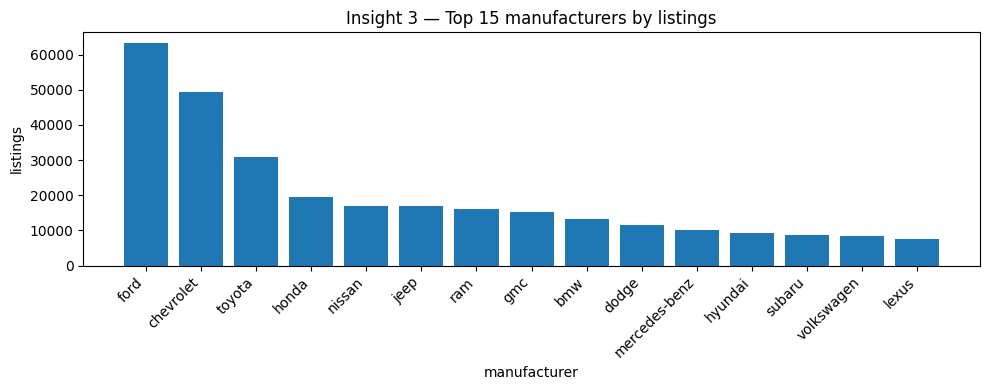

In [27]:
plot_bar_cat(df, 'manufacturer', 'listings', 'Insight 3 — Top 15 manufacturers by listings')

### Insight 4 — Median price by manufacturer (top 15 by listings)

```sql
WITH m AS (
  SELECT manufacturer, COUNT(*) AS listings
  FROM silver_vehicles
  WHERE manufacturer IS NOT NULL AND manufacturer != ''
  GROUP BY 1
  ORDER BY listings DESC
  LIMIT 15
)
SELECT s.manufacturer, MEDIAN(s.price) AS median_price
FROM silver_vehicles s
JOIN m USING(manufacturer)
GROUP BY 1
ORDER BY median_price DESC;
```

In [28]:
df = con.execute(r"""
WITH m AS (
  SELECT manufacturer, COUNT(*) AS listings
  FROM silver_vehicles
  WHERE manufacturer IS NOT NULL AND manufacturer != ''
  GROUP BY 1
  ORDER BY listings DESC
  LIMIT 15
)
SELECT s.manufacturer, MEDIAN(s.price) AS median_price
FROM silver_vehicles s
JOIN m USING(manufacturer)
GROUP BY 1
ORDER BY median_price DESC;
""").df()
df


,manufacturer,median_price
0,ram,29995.0
1,gmc,24500.0
2,lexus,19999.0
3,mercedes-benz,19898.0
4,jeep,18900.0
5,bmw,18500.0
6,ford,17000.0
7,chevrolet,16250.0
8,toyota,13995.0
9,dodge,12500.0


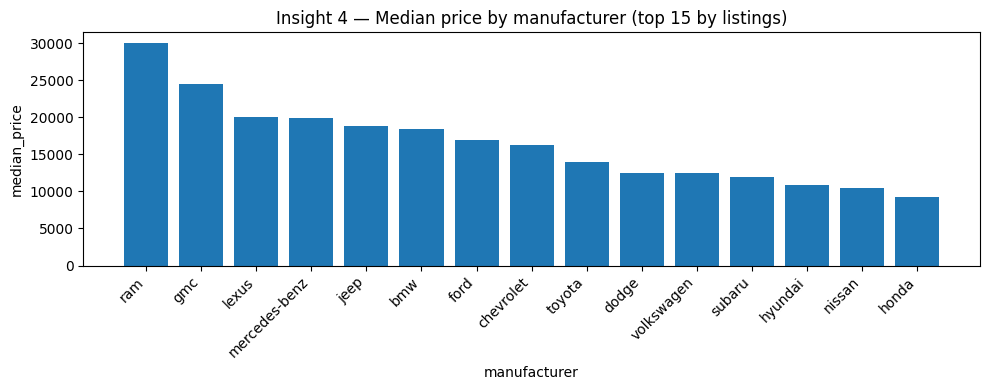

In [29]:
plot_bar_cat(df, 'manufacturer', 'median_price', 'Insight 4 — Median price by manufacturer (top 15 by listings)')

### Insight 5 — Median price by vehicle age (0–30)

```sql
SELECT vehicle_age, MEDIAN(price) AS median_price, COUNT(*) AS listings
FROM silver_vehicles
WHERE vehicle_age BETWEEN 0 AND 30
GROUP BY 1
HAVING COUNT(*) >= 500
ORDER BY 1;
```

In [30]:
df = con.execute(r"""SELECT vehicle_age, MEDIAN(price) AS median_price, COUNT(*) AS listings
FROM silver_vehicles
WHERE vehicle_age BETWEEN 0 AND 30
GROUP BY 1
HAVING COUNT(*) >= 500
ORDER BY 1;""").df()
df


,vehicle_age,median_price,listings
0,0,35990.0,1648
1,1,35990.0,17490
2,2,32590.0,22303
3,3,28995.0,31478
4,4,25995.0,31320
5,5,21990.0,26592
6,6,19900.0,27106
7,7,16989.0,26201
8,8,14000.0,27579
9,9,12499.0,21850


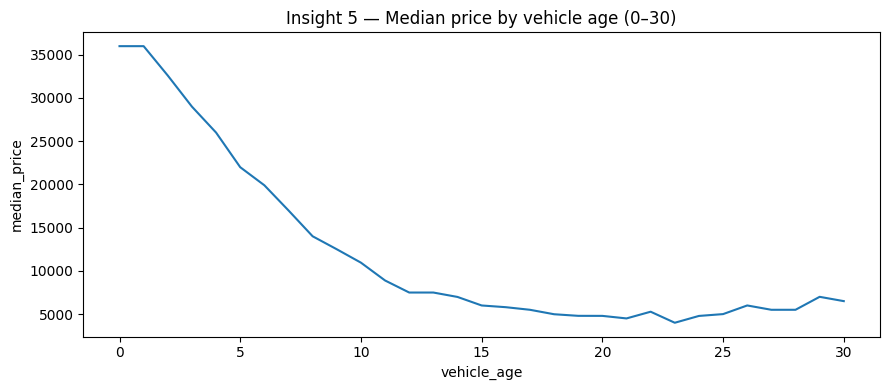

In [31]:
plot_line_num(df, 'vehicle_age', 'median_price', 'Insight 5 — Median price by vehicle age (0–30)')

### Insight 6 — Median price by odometer bin

```sql
WITH b AS (
  SELECT
    CASE
      WHEN odometer < 25000 THEN '0-25k'
      WHEN odometer < 50000 THEN '25k-50k'
      WHEN odometer < 100000 THEN '50k-100k'
      WHEN odometer < 150000 THEN '100k-150k'
      WHEN odometer < 200000 THEN '150k-200k'
      ELSE '200k+'
    END AS odo_bin,
    price
  FROM silver_vehicles
  WHERE odometer IS NOT NULL AND price IS NOT NULL
)
SELECT odo_bin, MEDIAN(price) AS median_price, COUNT(*) AS listings
FROM b
GROUP BY 1
ORDER BY listings DESC;
```

In [32]:
df = con.execute(r"""WITH b AS (
  SELECT
    CASE
      WHEN odometer < 25000 THEN '0-25k'
      WHEN odometer < 50000 THEN '25k-50k'
      WHEN odometer < 100000 THEN '50k-100k'
      WHEN odometer < 150000 THEN '100k-150k'
      WHEN odometer < 200000 THEN '150k-200k'
      ELSE '200k+'
    END AS odo_bin,
    price
  FROM silver_vehicles
  WHERE odometer IS NOT NULL AND price IS NOT NULL
)
SELECT odo_bin, MEDIAN(price) AS median_price, COUNT(*) AS listings
FROM b
GROUP BY 1
ORDER BY listings DESC;""").df()
df


,odo_bin,median_price,listings
0,50k-100k,16590.0,96809
1,100k-150k,9900.0,91392
2,0-25k,30590.0,62266
3,25k-50k,26500.0,57140
4,150k-200k,6900.0,50203
5,200k+,5497.0,22500


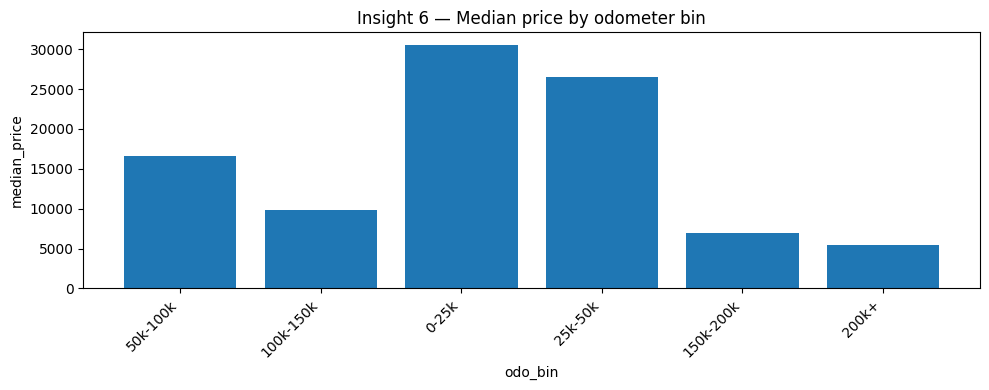

In [33]:
plot_bar_cat(df, 'odo_bin', 'median_price', 'Insight 6 — Median price by odometer bin')

### Insight 7 — Fuel type distribution

```sql
SELECT fuel, COUNT(*) AS listings
FROM silver_vehicles
WHERE fuel IS NOT NULL AND fuel != ''
GROUP BY 1
ORDER BY listings DESC;
```

In [34]:
df = con.execute(r"""
SELECT fuel, COUNT(*) AS listings
FROM silver_vehicles
WHERE fuel IS NOT NULL AND fuel != ''
GROUP BY 1
ORDER BY listings DESC;
""").df()
df


,fuel,listings
0,gas,320508
1,other,27387
2,diesel,25597
3,hybrid,4755
4,electric,1596


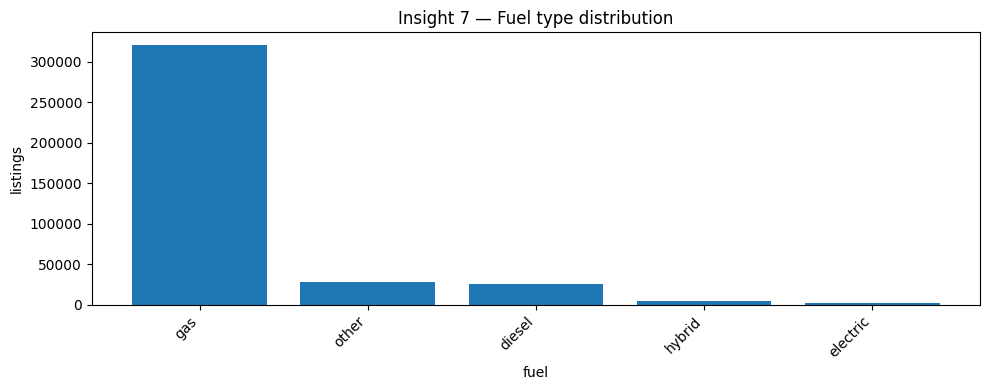

In [35]:
plot_bar_cat(df, 'fuel', 'listings', 'Insight 7 — Fuel type distribution')

### Insight 8 — Transmission: listings and median price

```sql
SELECT transmission, COUNT(*) AS listings, MEDIAN(price) AS median_price
FROM silver_vehicles
WHERE transmission IS NOT NULL AND transmission != ''
GROUP BY 1
ORDER BY listings DESC;
```

In [36]:
df = con.execute(r"""
SELECT transmission, COUNT(*) AS listings, MEDIAN(price) AS median_price
FROM silver_vehicles
WHERE transmission IS NOT NULL AND transmission != ''
GROUP BY 1
ORDER BY listings DESC;
""").df()
df


,transmission,listings,median_price
0,automatic,297649,13400.0
1,other,60662,28590.0
2,manual,22308,10000.0


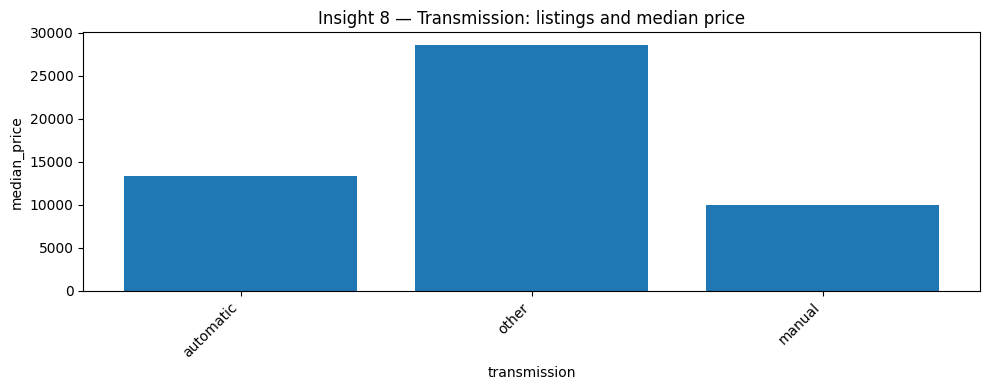

In [37]:
plot_bar_cat(df, 'transmission', 'median_price', 'Insight 8 — Transmission: listings and median price')

### Insight 9 — Top states by median price (min 3000 listings)

```sql
SELECT state, COUNT(*) AS listings, MEDIAN(price) AS median_price
FROM silver_vehicles
WHERE state IS NOT NULL AND state != ''
GROUP BY 1
HAVING COUNT(*) >= 3000
ORDER BY median_price DESC
LIMIT 15;
```

In [38]:
df = con.execute(r"""
SELECT state, COUNT(*) AS listings, MEDIAN(price) AS median_price
FROM silver_vehicles
WHERE state IS NOT NULL AND state != ''
GROUP BY 1
HAVING COUNT(*) >= 3000
ORDER BY median_price DESC
LIMIT 15;
""").df()
df


,state,listings,median_price
0,ak,3410,22988.0
1,mt,5954,22984.0
2,wa,11913,20999.0
3,al,4641,20400.0
4,mo,3862,19990.0
5,nm,3704,18990.0
6,ga,6230,18989.0
7,ar,3224,18959.0
8,sc,5596,18950.0
9,tx,20870,18926.5


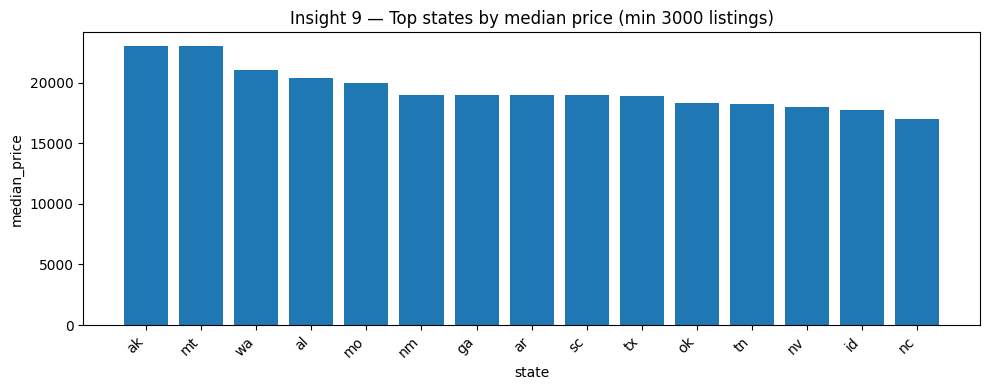

In [39]:
plot_bar_cat(df, 'state', 'median_price', 'Insight 9 — Top states by median price (min 3000 listings)')

### Insight 10 — Outliers: top 20 by price

```sql
SELECT posting_date, state, manufacturer, model, vehicle_year, odometer, price
FROM silver_vehicles
ORDER BY price DESC
LIMIT 20;
```

In [40]:
df = con.execute(r"""SELECT posting_date, state, manufacturer, model, vehicle_year, odometer, price
FROM silver_vehicles
ORDER BY price DESC
LIMIT 20;""").df()
df


,posting_date,state,manufacturer,model,vehicle_year,odometer,price
0,2021-04-23,tx,None,kenworth t800,2015,44126,200000
1,2021-05-04,va,None,intertational,2001,1000,200000
2,2021-04-11,va,None,intertational,2001,1000,200000
3,2021-04-12,fl,mercedes-benz,g-class,2017,15189,199999
4,2021-04-12,fl,mercedes-benz,g-class,2017,15189,199999
5,2021-04-12,fl,mercedes-benz,g-class,2017,15189,199999
6,2021-05-01,fl,None,lamborghini huracan,2015,33875,197999
7,2021-04-26,fl,None,lamborghini huracan,2015,33875,197999
8,2021-05-01,fl,None,lamborghini huracan,2015,33875,197999
9,2021-04-26,fl,None,lamborghini huracan,2015,33875,197999


_Table output only (no chart for this one)._